In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

In [7]:
import time

def generate_data(phi, num_samples, W, NOISE_VAR, W0=0, D=1, verbose=False):
    current_time_seed = int(time.time() * 1000)
    ch.manual_seed(current_time_seed)
    a, b = 0, 1
    
    x_trunc, y_trunc = ch.Tensor([]), ch.Tensor([])
    X, Y = ch.Tensor([]), ch.Tensor([])
    sampled = 0
    while x_trunc.size(0) < num_samples:
        x = (b - a) * ch.rand(num_samples, D) + a
                
        y = x @ W + W0 + (NOISE_VAR ** .5) * ch.randn(num_samples, 1)
        
        X = ch.cat([X, x])
        Y = ch.cat([Y, y])
        
        trunc_indices = phi(y).flatten().nonzero().flatten()

        y_trunc = ch.cat([y_trunc, y[trunc_indices]]) 
        x_trunc = ch.cat([x_trunc, x[trunc_indices]])
        sampled += num_samples

    alpha = x_trunc.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return x_trunc[:num_samples], y_trunc[:num_samples], alpha, X, Y

# One Dimension Regression - Varying Samples

In [3]:
W = ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 1000
W fit:
 [1.0428002]


In [4]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.702
trunc lin reg W:
 [[1.6161797]]


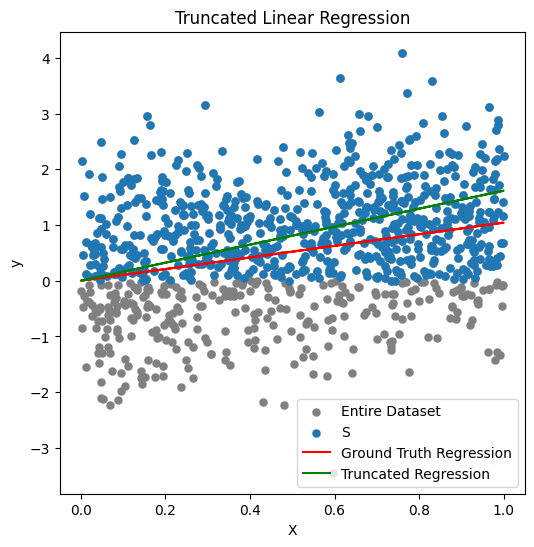

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

In [10]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 0

W = ch.ones(1, 1)

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
NUM_TRIALS = 2

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, 1)

        gt = LinearRegression(fit_intercept=False)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten()]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LinearRegression(fit_intercept=False)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_noise_var = ch.from_numpy(ols_trunc.predict(x_trunc) - y_trunc.numpy()).var(0)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten()]))

        emp_mse_loss = mse_loss(emp_, gt_).item()
        emp_var_l1 = float(ch.abs(emp_noise_var - gt_noise_var))

        y_trunc_emp_scale = y_trunc / ch.sqrt(emp_noise_var)

        args = Parameters({
                            'trials': 1,
                            'batch_size': 50,
                            'var_lr': 1e-1, 
                            'early_stopping': True,
                            'gradient_steps': num_samples,
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi,
                                                alpha, 
                                                fit_intercept=False)
        delphi_reg.fit(x_trunc, y_trunc_emp_scale)

        delphi_coef_ = delphi_reg.best_coef_ * (emp_noise_var ** .5)
        delphi_var_ = delphi_reg.best_variance_ * emp_noise_var

        delphi_mse = mse_loss(gt_, delphi_coef_.flatten()).item()
        delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))


        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'emp_var_l1': emp_var_l1, 
            'delphi_mse': delphi_mse, 
            'delphi_var_l1': delphi_var_l1
        }

        results.append(result)
    
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
trial: 1, num samples: 500
trial: 1, num samples: 1000
trial: 1, num samples: 2000
trial: 1, num samples: 3000
trial: 1, num samples: 4000
trial: 1, num samples: 5000
trial: 1, num samples: 6000
trial: 1, num samples: 7000


KeyboardInterrupt: 

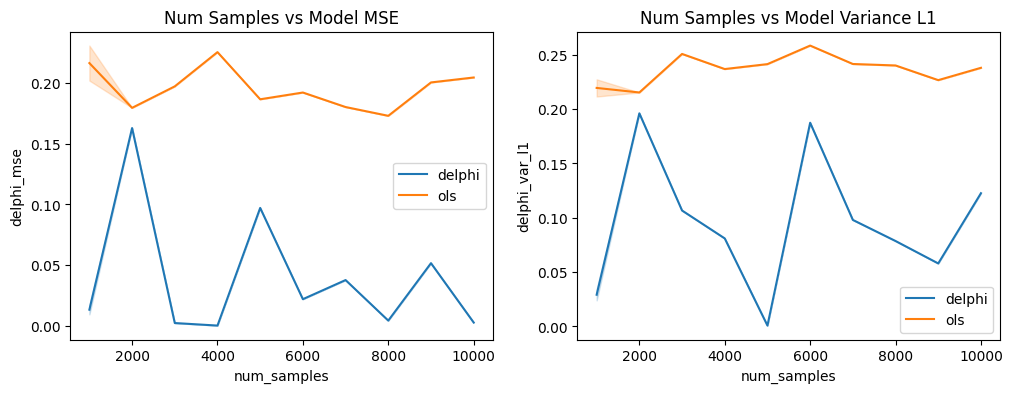

In [97]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax1, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax1, label="ols")
ax1.set_title('Num Samples vs Model MSE')

sns.lineplot(data=df, x="num_samples", y="delphi_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="ols")
ax2.set_title('Num Samples vs Model Variance L1')

plt.show()

In [103]:
df.groupby('num_samples').mean(), df.groupby('num_samples').var()

(              emp_mse  emp_var_l1  delphi_mse  delphi_var_l1
 num_samples                                                 
 1000         0.216591    0.219578    0.013151       0.029163
 2000         0.179658    0.215384    0.162990       0.196187
 3000         0.197385    0.250868    0.002132       0.106701
 4000         0.225629    0.236958    0.000037       0.081008
 5000         0.186726    0.241498    0.097094       0.000765
 6000         0.192305    0.258569    0.021820       0.187527
 7000         0.180329    0.241616    0.037585       0.098043
 8000         0.173080    0.240252    0.004142       0.078623
 9000         0.200626    0.226748    0.051519       0.057973
 10000        0.204703    0.238102    0.002567       0.122641,
               emp_mse  emp_var_l1  delphi_mse  delphi_var_l1
 num_samples                                                 
 1000         0.000208    0.000063    0.000015       0.000027
 2000         0.000000    0.000000    0.000000       0.000000
 3000  

In [109]:
df[['delphi_mse', 'num_samples']][df.num_samples == 1000]

,delphi_mse,num_samples
0,0.024175,1000
10,0.011926,1000
20,0.011926,1000
30,0.011926,1000
40,0.011926,1000
50,0.011926,1000
60,0.011926,1000
70,0.011926,1000
80,0.011926,1000
90,0.011926,1000
